# Image Classifier - Convolutional Neural Network (CNN)

In [1]:
import torch
print(torch.__version__)

2.8.0


In [2]:
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Setting up seed ensures results are reproducible and consistent across runs
torch.manual_seed(25)

#### Device Selection

Select the appropriate device (GPU/MPS for faster training, or CPU if unavailable).

In [3]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: mps


## Step 1: Data Preparation

In [4]:
default_data_path = "/Users/akshay/Work/data/"

#### CIFAR100 Dataset

`torchvision.datasets` has a collection of commonly used datasets for vision. **CIFAR100** is one of the most popular datasets used for training image classifiers. This dataset has 100 different class labels. It contains thousands of small, 32x32 color images.

Loading the dataset from `torchvision.datasets.CIFAR100`:
- `root` - default folder where files will be saved if not already downloaded
- `train` - setting this to `True`, loads the training partition
- `download` - automatically downloads if the dataset is not present

In [5]:
train_dataset = torchvision.datasets.CIFAR100(
    root=default_data_path,
    train=True,
    download=True,
)

In [6]:
image_pil, label = train_dataset[0]
print(f"Label: {label}")
print(f"Image size: {image_pil.size}")

Label: 19
Image size: (32, 32)


### Visualizing the Data

Display a sample image from the dataset to understand the data format.

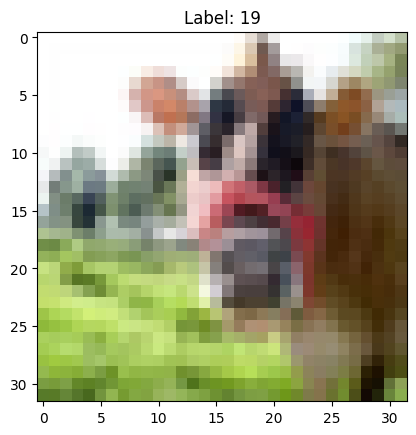

In [7]:
plt.imshow(image_pil)
plt.title(f"Label: {label}")
plt.show()

### Preparing the Data

#### Defining Transforms

Transforms help in transforming data to the appropriate model input format. `torchvision.transforms` natively supports various types of transformations.

`transforms.Compose()` bundles/chains together a sequence of transformation steps:
- `transforms.RandomHorizontalFlip()` Horizontally flip the given image randomly.
- `transforms.RandomRotation(15)` Rotates the image by a random angle selected within a specified range.
- `transforms.ToTensor()` converts images into PyTorch tensors
- `transforms.Normalize()` adjusts the values by centering them around mean and standard deviation

In [8]:
cifar100_mean = (0.5071, 0.4867, 0.4408)
cifar100_std = (0.2675, 0.2565, 0.2761)

In [9]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(cifar100_mean, cifar100_std)
])

Inspect the transformed data - images are now PyTorch tensors with shape [3, 32, 32] (channel, height, width).

Load the full training and evaluation datasets with the `transform` parameter applied. The transformed images are PyTorch tensors with shape `[3, 32, 32]` (channels, height, width).

In [10]:
subset_target_classes = [
    # Flowers
    'orchid', 'rose', 'sunflower',
    # Mammals
    'fox', 'lion', 'rabbit',
    # Insects
    'butterfly', 
    # people
    'boy', 'girl',
    # Things
    'castle'
]

In [11]:
full_train_dataset = torchvision.datasets.CIFAR100(
    root=default_data_path,
    train=True,
    transform=transform,
    download=True,
)

In [12]:
image_tensor, label = full_train_dataset[0]
print(f"Label: {label}")
print(f"Image tensor size: {image_tensor.size()}")
print(f"Image tensor min/max: {image_tensor.min()}/{image_tensor.max()}")

Label: 19
Image tensor size: torch.Size([3, 32, 32])
Image tensor min/max: -1.8974658250808716/2.025352954864502


In [13]:
full_eval_dataset = torchvision.datasets.CIFAR100(
    root=default_data_path,
    train=False,
    transform=transform,
    download=True,
)

#### Filtering and Remapping Labels

Filter both datasets to only include samples from the 10 target classes. Since the original CIFAR100 labels are non-contiguous (e.g., orchid=54, rose=70), remap them to a contiguous range `[0, 9]` so they match the model's 10 output neurons.

In [14]:
#Filtering the dataset to only include the target classes
class_to_idx = {cls: idx for idx, cls in enumerate(full_train_dataset.classes)}
target_class_indices = [class_to_idx[cls] for cls in subset_target_classes]

# Remap original CIFAR100 labels to contiguous range [0, num_classes-1]
label_remap = {orig_idx: new_idx for new_idx, orig_idx in enumerate(target_class_indices)}

train_filtered_indices = [i for i, (_, label) in enumerate(full_train_dataset) if label in target_class_indices]
train_dataset = torch.utils.data.Subset(full_train_dataset, train_filtered_indices)
print(f"Number of samples in filtered train dataset: {len(train_dataset)}")

eval_filtered_indices = [i for i, (_, label) in enumerate(full_eval_dataset) if label in target_class_indices]
eval_dataset = torch.utils.data.Subset(full_eval_dataset, eval_filtered_indices)
print(f"Number of samples in filtered eval dataset: {len(eval_dataset)}")

print(f"Label remap: {label_remap}")


Number of samples in filtered train dataset: 5000
Number of samples in filtered eval dataset: 1000
Label remap: {54: 0, 70: 1, 82: 2, 34: 3, 43: 4, 65: 5, 14: 6, 11: 7, 35: 8, 17: 9}


### Creating the Data Loaders

`DataLoader` batches the data and enables efficient iteration during training. Set `shuffle=True` for training to randomize the order of samples.

In [15]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True,
)

eval_loader = DataLoader(
    dataset=eval_dataset,
    batch_size=64,
    shuffle=False,
)

## Step 2: Define the Convolutional Neural Network (CNN) Model

Defining a custom neural network model by creating a class inheriting from `nn.Module`. As part of `nn.Module`, define two functions:
- `__init__` method: used to define and initialize key components of the model
- `forward` method: used to define the forward pass, the flow of data through the layers.

#### Modularization with `ConvBlock`

Instead of repeating the same Conv → BatchNorm → ReLU → Pool pattern for every layer, extract it into a reusable `ConvBlock` module. Each `ConvBlock` is itself an `nn.Module`, so it can be stacked inside an `nn.Sequential` to build the full convolutional backbone in a clean, readable way.

#### Layer Reference

**Convolution Layer `nn.Conv2d`** — applies a 2D convolution over the input
- `in_channels` — number of channels in the input image (e.g., 3 for RGB)
- `out_channels` — number of filters (feature maps) produced by the convolution
- `kernel_size` — size of the sliding convolution window (e.g., 3 means a 3x3 filter)
- `padding` — number of pixels added around the input border to control output spatial dimensions

**Batch Normalization `nn.BatchNorm2d`** — normalizes the output of the previous layer across the current mini-batch
- Stabilizes and accelerates training by reducing internal covariate shift.
- Applied after the convolution and before the activation function.
- `num_features` — number of channels (must match `out_channels` of the preceding Conv2d)

**Max Pooling `nn.MaxPool2d`** — downsamples the input by taking the maximum value in each pooling window
- `kernel_size` — size of the pooling window (e.g., 2 means a 2x2 window)
- `stride` — step size the window moves after each operation (e.g., 2 halves the spatial dimensions)

**Flatten `nn.Flatten()`** — reshapes the multi-dimensional feature maps into a 1D vector for the fully connected layers

**Fully Connected Layers**
- *Linear Layer `nn.Linear(in_features, out_features)`* — a dense layer that maps `in_features` inputs to `out_features` outputs via a learned weight matrix
- *Dropout Layer `nn.Dropout(p)`* — randomly zeroes a fraction `p` of inputs during training to reduce overfitting.
    - Randomly turning off neurons during training.
    - Hence does not rely too much on specific features or patterns.
    - Place the Dropout after the activation function before the classification layer.


In [16]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, c_kernel_size=3, p_kernel_size=2, stride=2, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, c_kernel_size, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(p_kernel_size, stride)
        )
        
    def forward(self, x):
        x = self.block(x)
        return x

In [32]:
class SimpleCNN(nn.Module):
    """"A simple Convolutional Neural Network for CIFAR100 10 class classification"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        """Initialize the model layers"""
        # Define layers

        #Conv Layer 1
        self.convblock = nn.Sequential(
            ConvBlock(in_channels=3, out_channels=32),
            ConvBlock(in_channels=32, out_channels=64),
            ConvBlock(in_channels=64, out_channels=128),
            ConvBlock(in_channels=128, out_channels=256)
        )

        # Flatten the output from the convolutional layers
        self.flatten = nn.Flatten()

        # Sequence of fully connected layers
        self.fc_layers = nn.Sequential(
            nn.Linear(256*2*2, 512),  # Adjust input size based on the output of conv layers
            nn.ReLU(),
            nn.Dropout(0.5),  # Dropout for regularization
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        """Forward pass of the model"""
        # Pass through Convolutional layers        
        x = self.convblock(x)
        # Flatten the output for the fully connected layers
        x = self.flatten(x)  
        # Pass through fully connected layers
        x = self.fc_layers(x) 
        return x

In [33]:
num_classes = len(subset_target_classes)
model = SimpleCNN(num_classes=num_classes)
# Move model to the selected device (CPU or GPU)
model.to(device)

SimpleCNN(
  (convblock): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool2d(kernel_size=2, st

#### Analysis of model parameters

In [34]:
print(model)

SimpleCNN(
  (convblock): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      )
    )
    (2): ConvBlock(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU()
        (3): MaxPool2d(kernel_size=2, st

In [35]:
print(model.parameters())

<generator object Module.parameters at 0x11705bae0>


In [36]:
for name, param in model.named_parameters():
    print(f"Layer: {name} | Size: {param.size()} | Requires Grad: {param.requires_grad}")

Layer: convblock.0.block.0.weight | Size: torch.Size([32, 3, 3, 3]) | Requires Grad: True
Layer: convblock.0.block.0.bias | Size: torch.Size([32]) | Requires Grad: True
Layer: convblock.0.block.1.weight | Size: torch.Size([32]) | Requires Grad: True
Layer: convblock.0.block.1.bias | Size: torch.Size([32]) | Requires Grad: True
Layer: convblock.1.block.0.weight | Size: torch.Size([64, 32, 3, 3]) | Requires Grad: True
Layer: convblock.1.block.0.bias | Size: torch.Size([64]) | Requires Grad: True
Layer: convblock.1.block.1.weight | Size: torch.Size([64]) | Requires Grad: True
Layer: convblock.1.block.1.bias | Size: torch.Size([64]) | Requires Grad: True
Layer: convblock.2.block.0.weight | Size: torch.Size([128, 64, 3, 3]) | Requires Grad: True
Layer: convblock.2.block.0.bias | Size: torch.Size([128]) | Requires Grad: True
Layer: convblock.2.block.1.weight | Size: torch.Size([128]) | Requires Grad: True
Layer: convblock.2.block.1.bias | Size: torch.Size([128]) | Requires Grad: True
Layer: 

In [37]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters in the model: {total_params}")

Total number of parameters in the model: 919306


## Step 3: Define Loss Function and Optimizer

- **Loss Function**: Measures the difference between predictions and actual values
- **Optimizer**: Updates model parameters (weights and biases) to minimize the loss
    - *Learning Rate `lr`*: Controls how much the optimizer adjusts parameters in each step
    - *Weight Decay `weight_decay`*: Regularization method. It works by discouraging the networks to use very large weights.
        - Large weights --> Overfitting
        - Weight Decay --> Add penalties for larger weights

In [38]:
loss_fn = nn.CrossEntropyLoss()  # Cross Entropy Loss, most commonly used for classification tasks
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0005)  # Adam Optimizer with learning rate 0.001

## Step 4: Training Loop

The training loop repeats the following steps for multiple epochs:
1. Reset gradients: Clear gradients from previous epochs
2. Forward pass: Make predictions
3. Calculate loss: Compare predictions with targets
4. Backward pass: Compute gradients
5. Update parameters: Adjust weights and biases

In [39]:
def train_model(train_loader, model, optimizer, loss_fn, device, label_remap=None):
    """
    Train the CNN model for CIFAR100 subset classification.
    
    Returns:
        model: Trained model
        avg_epoch_loss: Average training loss across all batches
        avg_epoch_accuracy: Average training accuracy across all batches
    """
    # make sure model is in training mode
    model.train()
    epoch_loss = 0.0
    epoch_accuracy = 0.0

    # Tracker for batch
    tracking_loss = 0.0
    total_tracking_predictions = 0
    correct_predictions = 0
    total_batches = len(train_loader)


    for b_id, (features, targets) in enumerate(train_loader, start=1):
        features, targets = features.to(device), targets.to(device)

        # Remap original CIFAR100 labels to contiguous [0, num_classes-1]
        if label_remap is not None:
            targets = torch.tensor([label_remap[t.item()] for t in targets], device=device)

        # Reset gradients to zero (gradients accumulate by default)
        optimizer.zero_grad()

        # Forward pass
        predictions = model(features)
        
        # Calculate loss
        loss = loss_fn(predictions, targets)

        # Backward pass
        loss.backward()

        # Update model parameters using computed gradients
        optimizer.step()

        # Update loss trackers
        batch_loss = loss.item()
        tracking_loss += batch_loss
        epoch_loss += batch_loss

        # Evaluate accuracy for the batch
        _, predicted_labels = torch.max(predictions, 1)
        batch_correct = (predicted_labels == targets).sum().item()
        correct_predictions += batch_correct
        total_tracking_predictions += targets.size(0)
        epoch_accuracy += batch_correct


        # Print progress every 10 batches
        if b_id % 10 == 0:
            avg_loss = tracking_loss / 10
            avg_pred_accuracy = correct_predictions / total_tracking_predictions * 100.0
            print(f'Batch [{b_id}/{total_batches}] | Loss: {avg_loss:.4f} | Accuracy: {avg_pred_accuracy:.2f}%')

            tracking_loss = 0.0
            total_tracking_predictions = 0
            correct_predictions = 0
    
    avg_epoch_loss = epoch_loss / total_batches
    avg_epoch_accuracy = epoch_accuracy / (total_batches * train_loader.batch_size) * 100.0

    return model, avg_epoch_loss, avg_epoch_accuracy

In [40]:
num_epochs = 15
train_losses = []
train_accuracies = []

print("Starting training...")
# Defining the training loop
for epoch in range(1, num_epochs + 1):
    model, train_loss, train_acc = train_model(train_loader, model, optimizer, loss_fn, device=device, label_remap=label_remap)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc/100.0)
    print("---------------------------------------------------------------------------------------------------")
    print(f'Epoch [{epoch}/{num_epochs}] | Training Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%')
    print("---------------------------------------------------------------------------------------------------")

Starting training...
Batch [10/79] | Loss: 2.1753 | Accuracy: 23.28%
Batch [20/79] | Loss: 1.8107 | Accuracy: 40.16%
Batch [30/79] | Loss: 1.7489 | Accuracy: 36.41%
Batch [40/79] | Loss: 1.5228 | Accuracy: 43.91%
Batch [50/79] | Loss: 1.5471 | Accuracy: 45.31%
Batch [60/79] | Loss: 1.4111 | Accuracy: 51.25%
Batch [70/79] | Loss: 1.5235 | Accuracy: 44.53%
---------------------------------------------------------------------------------------------------
Epoch [1/15] | Training Loss: 1.6489 | Accuracy: 40.98%
---------------------------------------------------------------------------------------------------
Batch [10/79] | Loss: 1.4219 | Accuracy: 48.59%
Batch [20/79] | Loss: 1.4317 | Accuracy: 47.66%
Batch [30/79] | Loss: 1.4030 | Accuracy: 49.84%
Batch [40/79] | Loss: 1.3236 | Accuracy: 51.72%
Batch [50/79] | Loss: 1.3166 | Accuracy: 52.97%
Batch [60/79] | Loss: 1.2702 | Accuracy: 53.12%
Batch [70/79] | Loss: 1.2070 | Accuracy: 55.62%
---------------------------------------------------

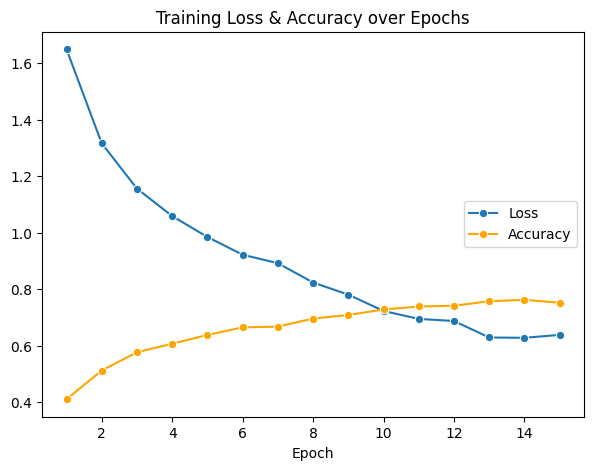

In [41]:
import seaborn as sns
# Plot training loss over epochs
plt.figure(figsize=(7, 5))
sns.lineplot(x=range(1, num_epochs + 1), y=train_losses, marker='o', label='Loss')
sns.lineplot(x=range(1, num_epochs + 1), y=train_accuracies, marker='o', color='orange', label='Accuracy')
plt.title('Training Loss & Accuracy over Epochs')
plt.legend(loc='center right')  # Position legend at center right
plt.xlabel('Epoch')
plt.show()

## Step 5: Evaluating the Model

Measure the trained model's accuracy on the held-out test set. Use `model.eval()` to set the model to evaluation mode and `torch.no_grad()` to disable gradient computation during inference (saves memory and computation).

In [42]:
def evaluate(model, test_loader, device, label_remap=None):
    """
    Evaluate the trained model on the test dataset.
    """
    total_correct_predictions = 0
    total_predictions = 0
    # model.eval() set the model to evaluation mode (does not evaluate model)
    model.eval()
    with torch.no_grad(): # Disable gradient calculation/tracking
        for features, targets in test_loader:
            features, targets = features.to(device), targets.to(device)

            if label_remap is not None:
                targets = torch.tensor([label_remap[t.item()] for t in targets], device=device)

            predictions = model(features)

            _, predicted_labels = torch.max(predictions, 1)
            correct_predictions = (predicted_labels == targets).sum().item()
            total_correct_predictions += correct_predictions
            total_predictions += targets.size(0)
        
        accuracy = total_correct_predictions / total_predictions * 100.0
        print(f'Test Accuracy: {accuracy:.2f}%')
        
        return accuracy

In [43]:
model_accuracy = evaluate(model, eval_loader, device, label_remap=label_remap)

Test Accuracy: 74.50%
